In [1]:
checkpoint_dir: str = "output/checkpoints_species_contrastive_top4orders"

In [2]:
import torch
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np

def extract_metrics(ckpt_path):
    metrics_keys = ["step", "loss", "loss_proto", "loss_seq", "acc_proto_top1", "acc_proto_top5", "acc_seq"]
    try:
        # weights_only=True is faster but ensure your custom classes/names are allowed
        checkpoint = torch.load(ckpt_path, mmap=True, map_location='cpu', weights_only=True)
        
        step = checkpoint["step"]
        if isinstance(step, torch.Tensor): step = step.item()

        # 1. Extract standard metrics
        entry = {"step": step}
        for m in metrics_keys[1:]:
            val = checkpoint.get(m)
            entry[m] = val.item() if isinstance(val, torch.Tensor) else val
            
        # 2. Check for the 100,000 step milestone
        milestone_data = None
        if step % 100000 == 0:
            # .clone().numpy() copies data into process RAM as a standard NumPy array
            emb = checkpoint["species_embeddings"]
            milestone_data = {
                "step": step,
                "species_embeddings": emb.clone().numpy(),
                "species_names": checkpoint["species_names"]
            }
            
        return entry, milestone_data

    except Exception as e:
        print(f"Error loading {ckpt_path}: {e}")
        return None

def load_checkpoints_parallel(checkpoint_dir, max_workers=None):
    checkpoint_dir = Path(checkpoint_dir)
    paths = sorted(list(checkpoint_dir.glob('step*.pt')))
    
    history = []
    milestones = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(extract_metrics, p) for p in paths]
        
        for future in as_completed(futures):
            result = future.result()
            if result:
                metrics, extra = result
                history.append(metrics)
                if extra:
                    milestones.append(extra)
                
    # Keep everything chronological
    history.sort(key=lambda x: x['step'])
    milestones.sort(key=lambda x: x['step'])
    
    return history, milestones

# Usage
history, milestones = load_checkpoints_parallel(checkpoint_dir)

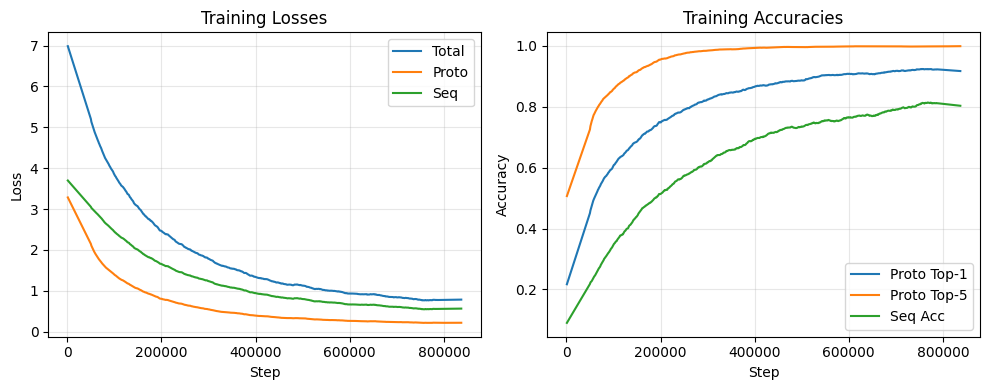

In [3]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def smooth(data, window_length=100, polyorder=1):
    return savgol_filter(data, window_length=window_length, polyorder=polyorder)

# Extract data for plotting
steps = [h['step'] for h in history]
losses = {
    'Total': smooth([h['loss'] for h in history]),
    'Proto': smooth([h['loss_proto'] for h in history]),
    'Seq': smooth([h['loss_seq'] for h in history])
}
accuracies = {
    'Proto Top-1': smooth([h['acc_proto_top1'] for h in history]),
    'Proto Top-5': smooth([h['acc_proto_top5'] for h in history]),
    'Seq Acc': smooth([h['acc_seq'] for h in history])
}

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Losses
for label, data in losses.items():
    ax1.plot(steps, data, label=label)
ax1.set_title('Training Losses')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracies
for label, data in accuracies.items():
    ax2.plot(steps, data, label=label)
ax2.set_title('Training Accuracies')
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import umap
import plotly.express as px

def plot_milestone_umap_with_orders(milestone_entry, csv_path):
    # 1. Load Taxonomy CSV
    # Assumes columns: 'species' (matching your model names) and 'order'
    taxonomy_df = pd.read_csv(csv_path)
    
    # 2. Extract Milestone Data
    step = milestone_entry['step']
    embeddings = milestone_entry['species_embeddings']
    species_names = milestone_entry['species_names']
    
    # 3. Dimensionality Reduction
    print(f"Running UMAP for step {step}...")
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42, metric='cosine')
    embedding_2d = reducer.fit_transform(embeddings)
    
    # 4. Prepare Plotting DataFrame
    df_plot = pd.DataFrame({
        'x': embedding_2d[:, 0],
        'y': embedding_2d[:, 1],
        'species': species_names
    })
    
    # Merge with CSV data to get the 'order' column
    # Use left merge to keep all model species even if they aren't in the CSV
    df_plot = df_plot.merge(taxonomy_df[['species', 'order', 'family', 'genus']], on='species', how='left')
    df_plot['order'] = df_plot['order'].fillna('Unknown') # Handle missing matches
    df_plot['family'] = df_plot['family'].fillna('Unknown')
    df_plot['genus'] = df_plot['genus'].fillna('Unknown')
    
    # 5. Plot with Plotly
    fig = px.scatter(
        df_plot, x='x', y='y', 
        color='order',
        hover_name='species',
        hover_data=['family', 'genus'],  # This adds family to the popup box
        title=f'UMAP (Step {step})',
        template='plotly_dark',
        width=1000, height=800
    )

    
    # Optional: Improve visual clarity
    fig.update_traces(marker=dict(size=6, opacity=0.8))
    fig.show()

# Usage
plot_milestone_umap_with_orders(milestones[-1], 'output/processed_dataset_taxonomy.csv')


Running UMAP for step 800000...


/vol/home/s2063131/MMEB/FishPhyloEmbedding2/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/vol/home/s2063131/MMEB/FishPhyloEmbedding2/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
